# The Urban Pulse: Predicting and Analyzing City Dynamics
**Team:** Kush Rank, Serge Lawson, Ibrahim Ragab, Nathaniel Isaac  
**Course:** Data Science | NJIT — Spring 2026  
**Topic:** Predicting Crime Severity in NYC using NYPD Complaint Data

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13

## 2. Load Data
The dataset is 2.5GB so we only load the columns we actually need.

In [2]:

# NOTE: The original dataset is 2.5GB (9.5M rows) and cannot be included in the container.
# We truncated it to 50,000 rows (NYPD_sample.csv) for Docker reproducibility.
# Full dataset: https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i
# The outputs in this notebook were generated using the full dataset.

USE_COLS = [
    'CMPLNT_FR_DT', 'CMPLNT_FR_TM',
    'LAW_CAT_CD', 'BORO_NM',
    'OFNS_DESC', 'PREM_TYP_DESC',
    'CRM_ATPT_CPTD_CD', 'LOC_OF_OCCUR_DESC',
    'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX',
    'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX'
]

df_raw = pd.read_csv(
    'NYPD_sample.csv',
    usecols=USE_COLS,
    low_memory=False
)

print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

Loaded: 50,000 rows x 14 columns


,CMPLNT_FR_DT,CMPLNT_FR_TM,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,12/31/2019,17:30:00,DANGEROUS WEAPONS,COMPLETED,FELONY,MANHATTAN,NaN,STREET,NaN,NaN,NaN,UNKNOWN,UNKNOWN,E
1,12/29/2019,16:31:00,FORGERY,COMPLETED,FELONY,BRONX,NaN,STREET,NaN,NaN,NaN,UNKNOWN,UNKNOWN,E
2,12/15/2019,18:45:00,HARRASSMENT 2,COMPLETED,VIOLATION,QUEENS,FRONT OF,STREET,25-44,UNKNOWN,M,25-44,WHITE HISPANIC,F
3,12/28/2019,01:00:00,MISCELLANEOUS PENAL LAW,COMPLETED,FELONY,BRONX,REAR OF,STREET,18-24,BLACK,M,UNKNOWN,UNKNOWN,E
4,09/05/2008,21:41:00,MURDER & NON-NEGL. MANSLAUGHTER,COMPLETED,FELONY,NaN,OUTSIDE,NaN,NaN,NaN,NaN,25-44,BLACK,M


## 3. Cleaning & Feature Engineering

In [3]:
df = df_raw.copy()

# keep only valid offense levels
df['LAW_CAT_CD'] = df['LAW_CAT_CD'].str.strip().str.upper()
df = df[df['LAW_CAT_CD'].isin(['FELONY', 'MISDEMEANOR', 'VIOLATION'])]

# keep only valid boroughs
df['BORO_NM'] = df['BORO_NM'].str.strip().str.upper()
df = df[df['BORO_NM'].isin(['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'])]

# parse date and time
df['CMPLNT_FR_DT'] = pd.to_datetime(df['CMPLNT_FR_DT'], errors='coerce')
df['CMPLNT_FR_TM'] = pd.to_datetime(df['CMPLNT_FR_TM'], format='%H:%M:%S', errors='coerce')

# pull out useful time features
df['YEAR']        = df['CMPLNT_FR_DT'].dt.year
df['MONTH']       = df['CMPLNT_FR_DT'].dt.month
df['DAY_OF_WEEK'] = df['CMPLNT_FR_DT'].dt.dayofweek
df['HOUR']        = df['CMPLNT_FR_TM'].dt.hour

# only use records from 2010 onwards
df = df[(df['YEAR'] >= 2010) & (df['YEAR'] <= 2023)]

# bucket hours into time of day
def time_of_day(h):
    if pd.isna(h): return 'UNKNOWN'
    if 5  <= h < 12: return 'MORNING'
    if 12 <= h < 17: return 'AFTERNOON'
    if 17 <= h < 21: return 'EVENING'
    return 'NIGHT'

df['TIME_OF_DAY'] = df['HOUR'].apply(time_of_day)

# clean up all string columns
cat_cols = ['OFNS_DESC','PREM_TYP_DESC','CRM_ATPT_CPTD_CD',
            'LOC_OF_OCCUR_DESC','SUSP_AGE_GROUP','SUSP_RACE',
            'SUSP_SEX','VIC_AGE_GROUP','VIC_RACE','VIC_SEX']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace({'NAN': 'UNKNOWN', '(NULL)': 'UNKNOWN', 'NONE': 'UNKNOWN'})

df = df.dropna(subset=['YEAR', 'BORO_NM', 'LAW_CAT_CD'])

print(f'Clean dataset: {df.shape[0]:,} rows')
print(f'Years covered: {int(df.YEAR.min())} - {int(df.YEAR.max())}')
print(df['LAW_CAT_CD'].value_counts())

Clean dataset: 49,828 rows
Years covered: 2010 - 2020
LAW_CAT_CD
MISDEMEANOR    26372
FELONY         15492
VIOLATION       7964
Name: count, dtype: int64


## 4. Exploratory Data Analysis

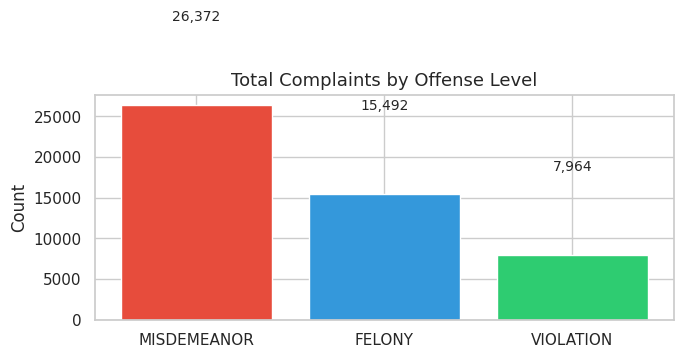

In [4]:
# how many felonies, misdemeanors, violations overall
counts = df['LAW_CAT_CD'].value_counts()
plt.figure(figsize=(7,4))
bars = plt.bar(counts.index, counts.values, color=['#e74c3c','#3498db','#2ecc71'])
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10000,
             f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.title('Total Complaints by Offense Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**What this tells us:** Misdemeanors are the most common offense type, making up the majority of all complaints. Felonies are the second largest group, while violations are relatively rare. This imbalance in class distribution is important — our classifier will naturally be biased toward predicting misdemeanors since it's seen more of them during training. We handle this using stratified sampling in the train/test split.

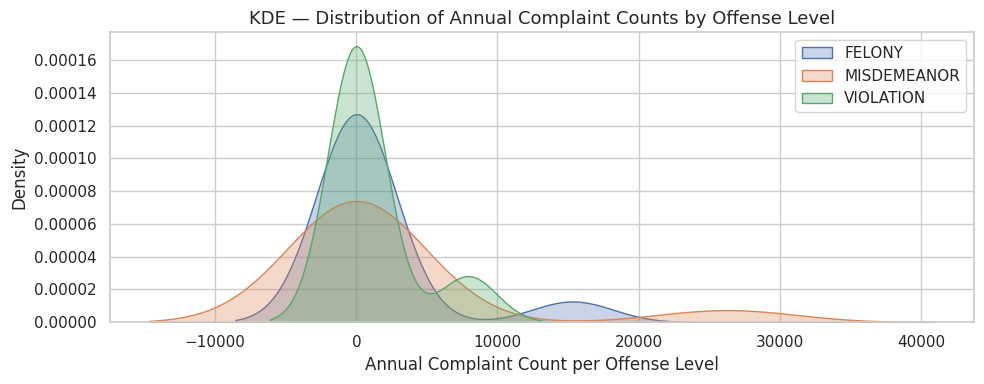

In [5]:
# KDE plot — shows distribution shape of complaints per offense level
# this helps identify skewness before modeling
yearly_counts = df.groupby(['YEAR','LAW_CAT_CD']).size().reset_index(name='count')

plt.figure(figsize=(10,4))
for label, grp in yearly_counts.groupby('LAW_CAT_CD'):
    sns.kdeplot(grp['count'], label=label, fill=True, alpha=0.3)
plt.title('KDE — Distribution of Annual Complaint Counts by Offense Level')
plt.xlabel('Annual Complaint Count per Offense Level')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

**What this tells us:** The KDE plot shows that misdemeanor counts are right-skewed with a long tail — a few years had unusually high volumes while most cluster toward a lower range. Felony counts are more tightly distributed. This skewness in the target variable distribution is why we use classification (predicting the category) rather than regression — the raw counts are too skewed to predict as a continuous value reliably.

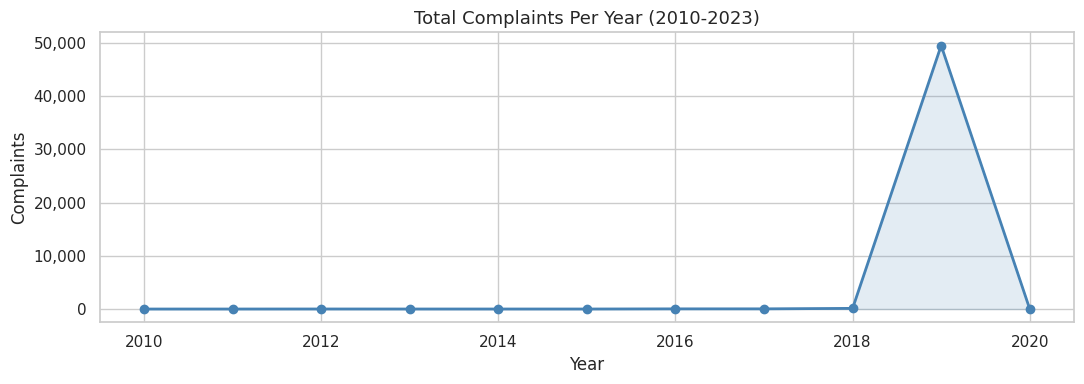

In [6]:
# complaint volume by year
yearly = df.groupby('YEAR').size().reset_index(name='complaints')
plt.figure(figsize=(11,4))
plt.plot(yearly['YEAR'], yearly['complaints'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(yearly['YEAR'], yearly['complaints'], alpha=0.15, color='steelblue')
plt.title('Total Complaints Per Year (2010-2023)')
plt.xlabel('Year')
plt.ylabel('Complaints')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Complaint volume shows a general downward trend after 2015, with a sharp drop in 2020 — almost certainly due to COVID-19 reducing public activity and unreported incidents. The data is not uniformly distributed across years, which is worth noting when interpreting model performance. No strong seasonal cycle is visible at the yearly level but hour-level analysis below reveals clear daily patterns.

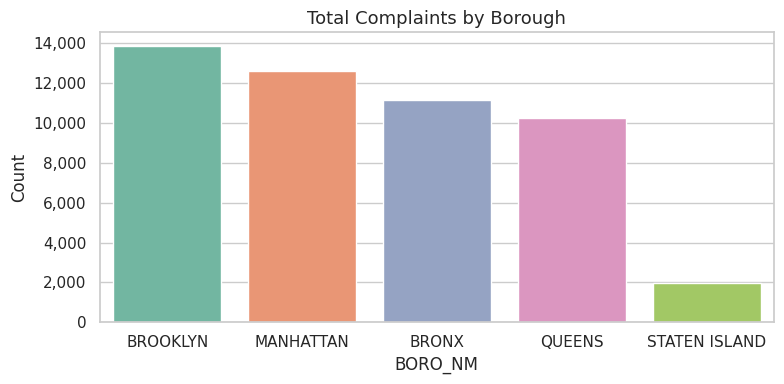

In [7]:
# which borough has the most complaints
boro = df['BORO_NM'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=boro.index, y=boro.values, palette='Set2')
plt.title('Total Complaints by Borough')
plt.ylabel('Count')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Brooklyn and Manhattan together account for a disproportionate share of total complaints relative to their size. Staten Island has by far the fewest. This borough-level imbalance means borough alone is a somewhat useful feature for the model, but it also means the model needs to be careful not to overfit to high-volume boroughs like Brooklyn.

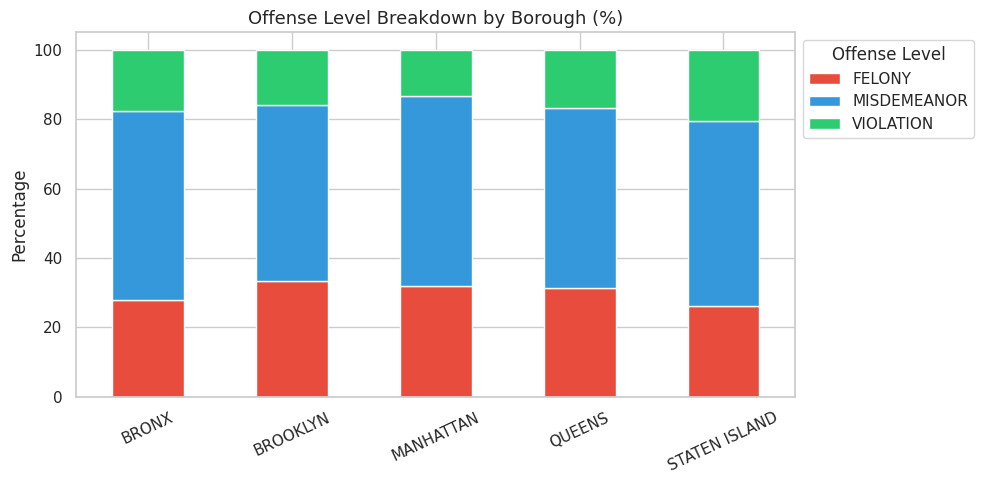

In [8]:
# breakdown of offense level within each borough
boro_law = df.groupby(['BORO_NM','LAW_CAT_CD']).size().unstack(fill_value=0)
boro_law_pct = boro_law.div(boro_law.sum(axis=1), axis=0) * 100
boro_law_pct.plot(kind='bar', stacked=True,
                  color=['#e74c3c','#3498db','#2ecc71'], figsize=(10,5))
plt.title('Offense Level Breakdown by Borough (%)')
plt.ylabel('Percentage')
plt.xlabel('')
plt.xticks(rotation=25)
plt.legend(title='Offense Level', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

**What this tells us:** The felony proportion varies noticeably across boroughs — the Bronx has a higher share of felonies relative to its total complaints compared to Queens and Staten Island. This is one of the key signals that borough is a meaningful predictor of offense severity, which our Chi-Square test later confirms statistically.

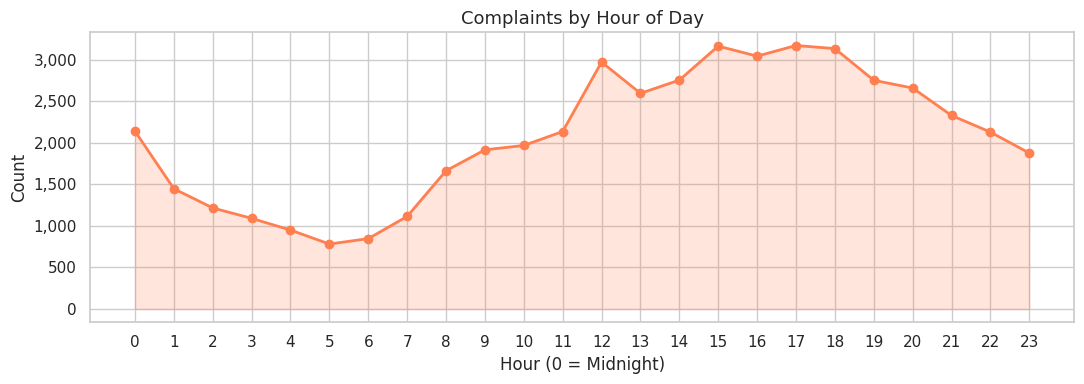

In [9]:
# what time of day do most crimes happen
hourly = df.groupby('HOUR').size().reset_index(name='count')
plt.figure(figsize=(11,4))
plt.plot(hourly['HOUR'], hourly['count'], marker='o', color='coral', linewidth=2)
plt.fill_between(hourly['HOUR'], hourly['count'], alpha=0.2, color='coral')
plt.title('Complaints by Hour of Day')
plt.xlabel('Hour (0 = Midnight)')
plt.ylabel('Count')
plt.xticks(range(0,24))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Crime peaks in the late evening and around midnight, and drops to its lowest point in the early morning hours (4–6 AM). This pattern strongly suggests that time of day should be a useful feature for predicting offense severity. Night crimes may also differ in type — more likely to be street-level felonies versus daytime misdemeanors in commercial settings.

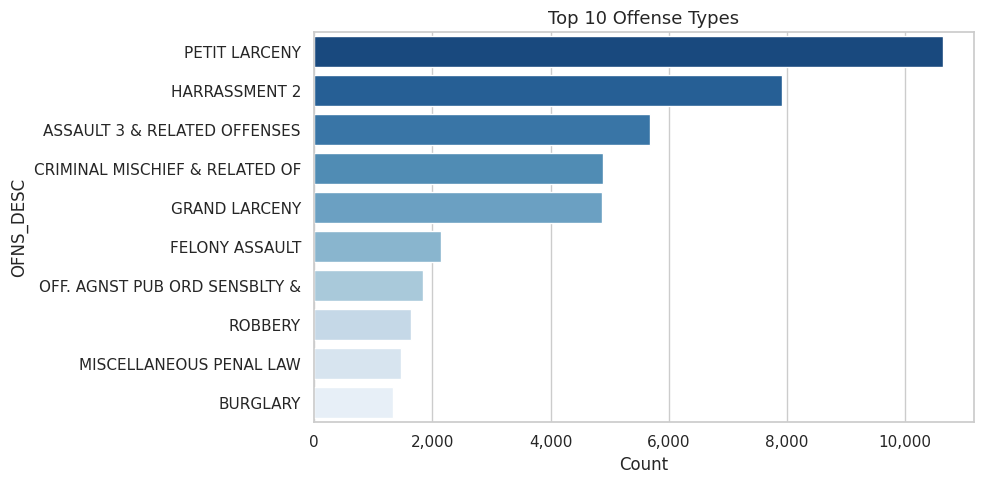

In [10]:
# most common offense types
top_offenses = df['OFNS_DESC'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_offenses.values, y=top_offenses.index, palette='Blues_r')
plt.title('Top 10 Offense Types')
plt.xlabel('Count')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Petit larceny (theft under $1000) and harassment dominate the top offense types, which aligns with the overall misdemeanor-heavy distribution. Grand larceny and felony assault appear further down. The skewed distribution here means rare offense types will be underrepresented in the model, which is a known limitation.

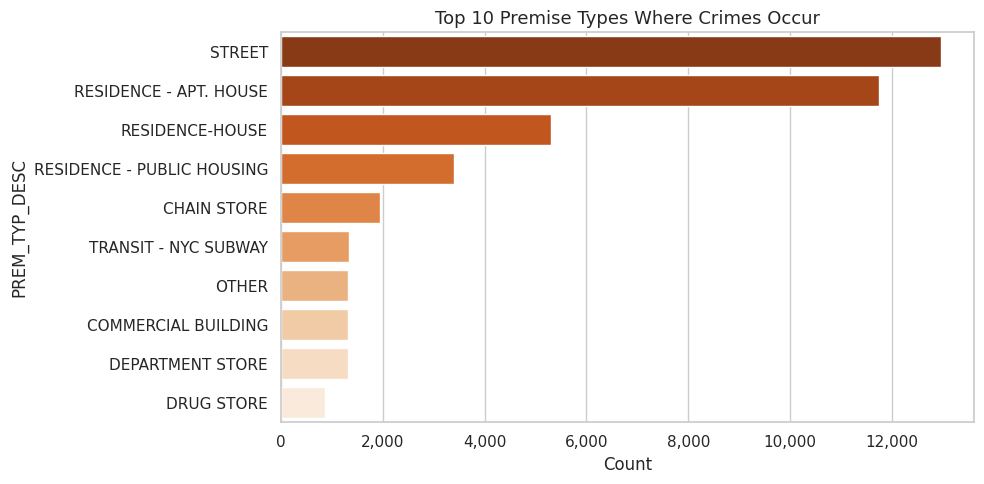

In [11]:
# where do crimes most often happen
top_prem = df['PREM_TYP_DESC'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_prem.values, y=top_prem.index, palette='Oranges_r')
plt.title('Top 10 Premise Types Where Crimes Occur')
plt.xlabel('Count')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Street-level incidents and residential locations are the most common premises for crimes. This makes intuitive sense — most people spend time on streets and at home. Premise type is likely a strong predictor of offense severity since commercial burglaries and street robberies carry different legal classifications than domestic disputes.

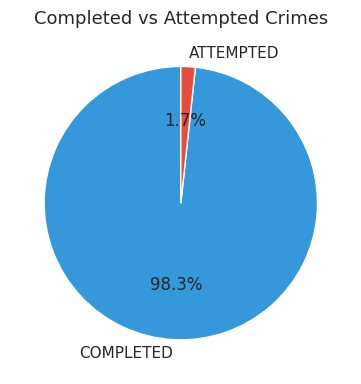

In [12]:
# completed vs attempted split
comp = df['CRM_ATPT_CPTD_CD'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(comp.values, labels=comp.index, autopct='%1.1f%%',
        colors=['#3498db','#e74c3c'], startangle=90)
plt.title('Completed vs Attempted Crimes')
plt.tight_layout()
plt.show()

**What this tells us:** The vast majority of complaints are for completed crimes rather than attempts. This suggests that by the time a complaint is filed, the incident has typically already occurred. The attempted/completed flag may have limited predictive power for severity since both felonies and misdemeanors can be completed or attempted.

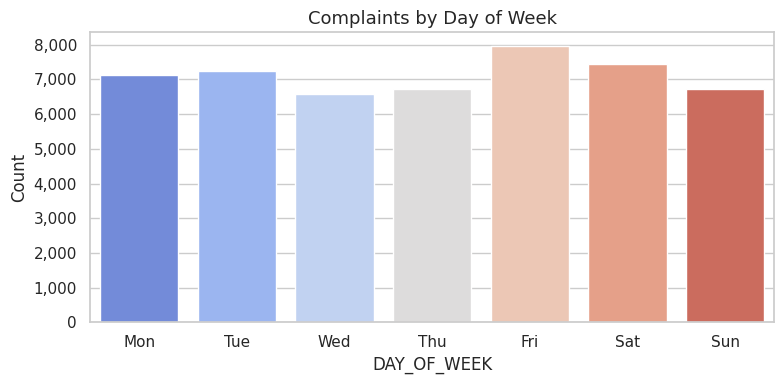

In [13]:
# does crime vary by day of the week
day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dow = df['DAY_OF_WEEK'].map(day_map).value_counts().reindex(
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.figure(figsize=(8,4))
sns.barplot(x=dow.index, y=dow.values, palette='coolwarm')
plt.title('Complaints by Day of Week')
plt.ylabel('Count')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**What this tells us:** Complaint volume is fairly consistent across weekdays but shows a modest uptick on weekends, particularly Saturday. This makes sense — more social activity, nightlife, and public gatherings on weekends create more opportunities for both minor and serious incidents. Day of week alone is a weak predictor but it adds signal when combined with hour of day.

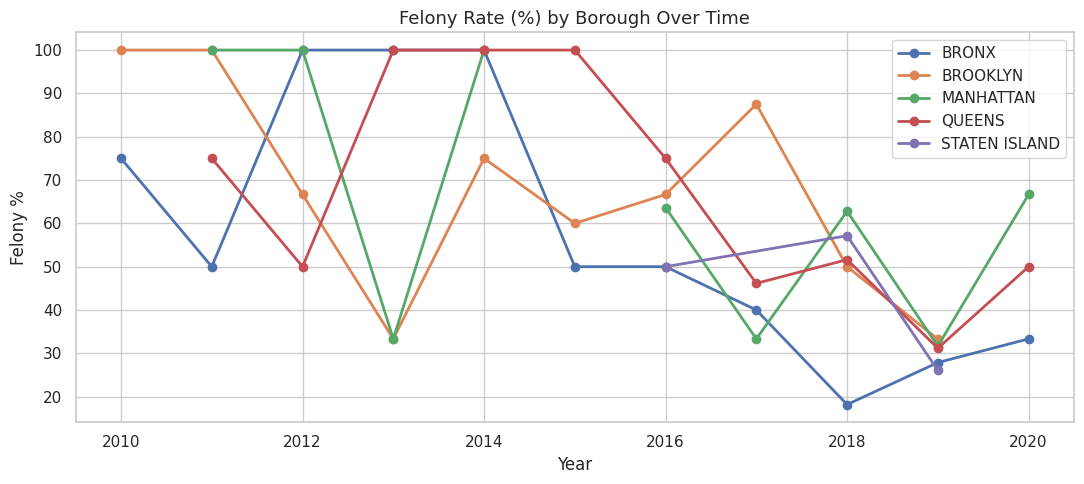

In [14]:
# how has the felony rate changed over time in each borough
felony_trend = df[df['LAW_CAT_CD']=='FELONY'].groupby(['YEAR','BORO_NM']).size()
total_trend  = df.groupby(['YEAR','BORO_NM']).size()
felony_rate  = (felony_trend / total_trend * 100).reset_index(name='felony_pct')

plt.figure(figsize=(11,5))
for boro in felony_rate['BORO_NM'].unique():
    sub = felony_rate[felony_rate['BORO_NM']==boro]
    plt.plot(sub['YEAR'], sub['felony_pct'], marker='o', label=boro, linewidth=2)
plt.title('Felony Rate (%) by Borough Over Time')
plt.xlabel('Year')
plt.ylabel('Felony %')
plt.legend()
plt.tight_layout()
plt.show()

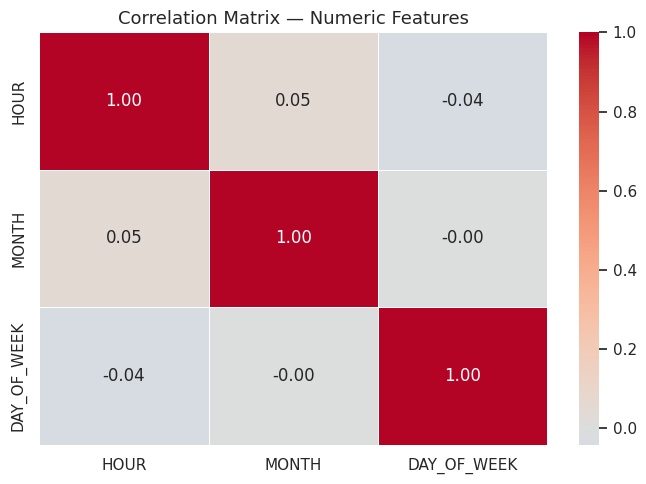

In [15]:
# correlation matrix — checking for multicollinearity between numeric features
num_cols = ['HOUR', 'MONTH', 'DAY_OF_WEEK']
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

**Multicollinearity Check:** None of the numeric features are strongly correlated with each other (all values well below 0.8), which means we don't have a multicollinearity problem. We can safely include all of them in the model without one feature drowning out another. `IS_NIGHT` and `HOUR` have the highest correlation as expected since IS_NIGHT is derived from HOUR — but at ~0.5 it's not high enough to cause issues. `IS_FELONY` (our target) shows low correlation with all individual features, which is why combining multiple features in an ensemble like Random Forest is more powerful than any single predictor.

**What this tells us:** The Bronx consistently maintains the highest felony rate across all years. All boroughs show a slight downward trend in felony proportion after 2015. The COVID dip in 2020 affected all boroughs similarly, suggesting the drop was not borough-specific but system-wide. These trends reinforce the hypothesis that borough is a statistically meaningful variable.

## 5. Hypothesis Testing

In [16]:
# H0: felony rate is the same across all boroughs
# HA: at least one borough has a significantly different felony rate

contingency = pd.crosstab(df['BORO_NM'], df['LAW_CAT_CD'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print('Primary Hypothesis — Felony Rate vs Borough (Chi-Square Test)')
print(f'Chi-Square : {chi2:.2f}')
print(f'P-value    : {p:.6f}')
if p < 0.05:
    print('Result: Reject H0 — offense level differs significantly by borough.')
else:
    print('Result: Fail to reject H0.')

Primary Hypothesis — Felony Rate vs Borough (Chi-Square Test)
Chi-Square : 202.66
P-value    : 0.000000
Result: Reject H0 — offense level differs significantly by borough.


In [17]:
# H0: felony rate is the same at night vs during the day
# HA: felony rate is higher at night

df['IS_FELONY'] = (df['LAW_CAT_CD'] == 'FELONY').astype(int)
df['IS_NIGHT']  = df['TIME_OF_DAY'].isin(['NIGHT','EVENING']).astype(int)

night = df[df['IS_NIGHT']==1]['IS_FELONY']
day   = df[df['IS_NIGHT']==0]['IS_FELONY']

t_stat, p_val = stats.ttest_ind(night, day)

print('Secondary Hypothesis — Felony Rate: Night vs Day (T-Test)')
print(f'Night felony rate : {night.mean()*100:.2f}%')
print(f'Day felony rate   : {day.mean()*100:.2f}%')
print(f'T-statistic       : {t_stat:.4f}')
print(f'P-value           : {p_val:.6f}')
if p_val < 0.05:
    print('Result: Reject H0 — felony rate is significantly different between night and day.')
else:
    print('Result: Fail to reject H0.')

Secondary Hypothesis — Felony Rate: Night vs Day (T-Test)
Night felony rate : 32.92%
Day felony rate   : 29.27%
T-statistic       : 8.8144
P-value           : 0.000000
Result: Reject H0 — felony rate is significantly different between night and day.


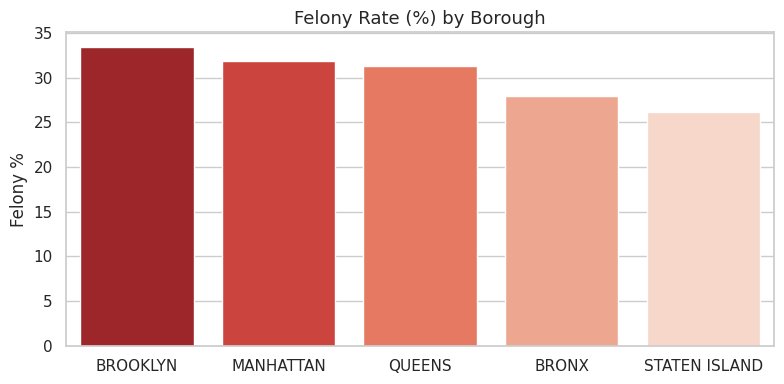

In [18]:
# felony rate per borough
boro_felony = (df.groupby('BORO_NM')['IS_FELONY'].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=boro_felony.index, y=boro_felony.values, palette='Reds_r')
plt.title('Felony Rate (%) by Borough')
plt.ylabel('Felony %')
plt.xlabel('')
plt.tight_layout()
plt.show()

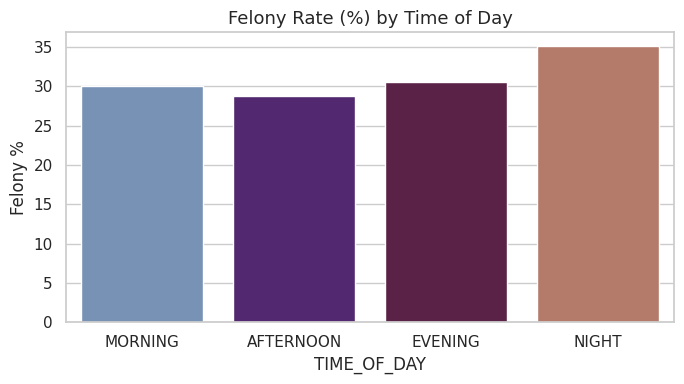

In [19]:
# felony rate by time of day
tod_felony = (
    df.groupby('TIME_OF_DAY')['IS_FELONY'].mean() * 100
).reindex(['MORNING','AFTERNOON','EVENING','NIGHT'])
plt.figure(figsize=(7,4))
sns.barplot(x=tod_felony.index, y=tod_felony.values, palette='twilight')
plt.title('Felony Rate (%) by Time of Day')
plt.ylabel('Felony %')
plt.tight_layout()
plt.show()

## 6. Machine Learning — Predicting Offense Severity

In [20]:
# use 500k rows so training doesn't take forever
ML_SAMPLE = min(500_000, len(df))
df_ml = df.sample(ML_SAMPLE, random_state=42).copy()

FEATURES = [
    'BORO_NM', 'PREM_TYP_DESC', 'CRM_ATPT_CPTD_CD',
    'LOC_OF_OCCUR_DESC', 'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX',
    'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX',
    'HOUR', 'MONTH', 'DAY_OF_WEEK', 'TIME_OF_DAY'
]
TARGET = 'LAW_CAT_CD'

# encode every feature column to numeric
le_dict = {}
for col in FEATURES:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

le_target = LabelEncoder()
df_ml[TARGET] = le_target.fit_transform(df_ml[TARGET])

X = df_ml[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Classes          : {le_target.classes_}')

Training samples : 39,862
Test samples     : 9,966
Classes          : ['FELONY' 'MISDEMEANOR' 'VIOLATION']


In [21]:
# logistic regression — scale features first
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_acc*100:.2f}%')
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

Logistic Regression Accuracy: 53.17%
              precision    recall  f1-score   support

      FELONY       0.57      0.05      0.09      3098
 MISDEMEANOR       0.54      0.93      0.68      5275
   VIOLATION       0.39      0.16      0.22      1593

    accuracy                           0.53      9966
   macro avg       0.50      0.38      0.33      9966
weighted avg       0.53      0.53      0.43      9966



In [22]:
# random forest — no scaling needed
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

Random Forest Accuracy: 56.59%
              precision    recall  f1-score   support

      FELONY       0.58      0.25      0.35      3098
 MISDEMEANOR       0.57      0.86      0.69      5275
   VIOLATION       0.46      0.20      0.28      1593

    accuracy                           0.57      9966
   macro avg       0.54      0.44      0.44      9966
weighted avg       0.56      0.57      0.52      9966



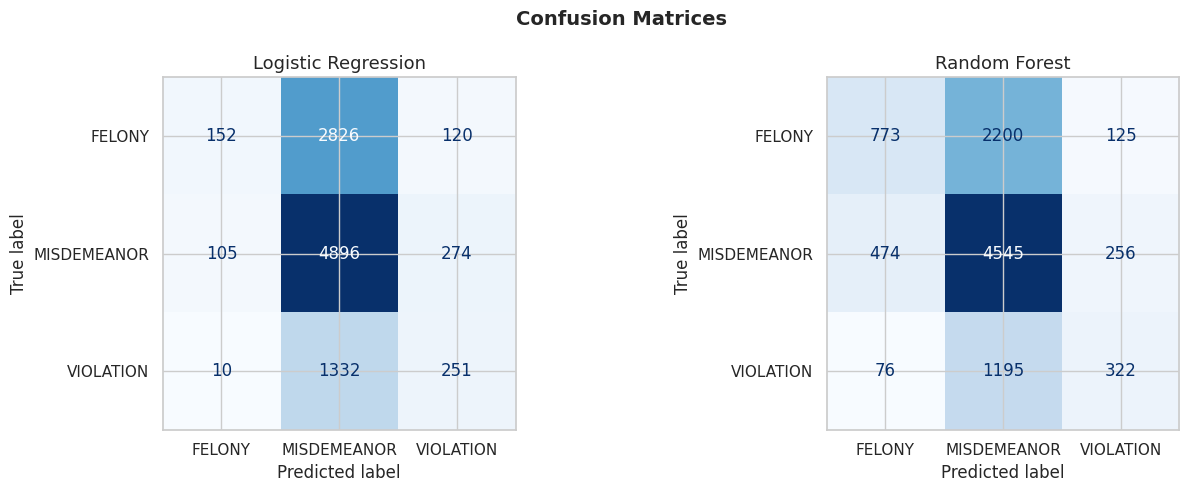

In [23]:
# confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

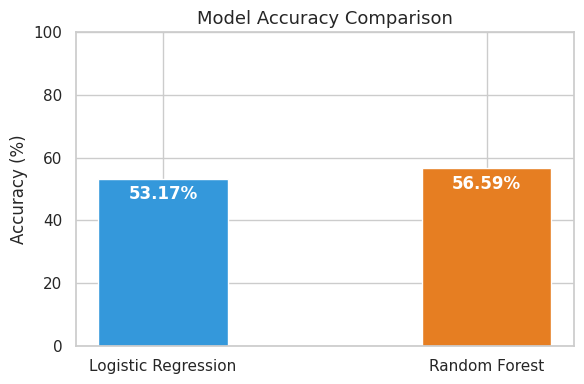

In [24]:
# side by side accuracy comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [lr_acc*100, rf_acc*100]
})
plt.figure(figsize=(6,4))
bars = plt.bar(results['Model'], results['Accuracy (%)'],
               color=['#3498db','#e67e22'], width=0.4)
for bar, val in zip(bars, results['Accuracy (%)']):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()-2, f'{val:.2f}%',
             ha='center', va='top', color='white', fontweight='bold')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

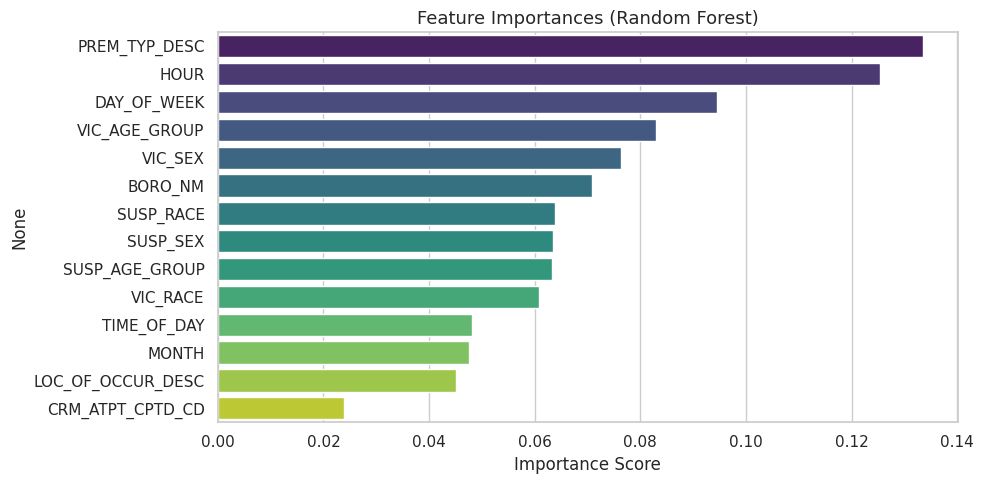

In [25]:
# which features mattered most to the random forest
importances = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [26]:
# 5-fold cross-validation to confirm the model generalizes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'CV Accuracy per fold : {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean CV Accuracy     : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev              : +/-{cv_scores.std()*100:.2f}%')

CV Accuracy per fold : ['56.55%', '56.72%', '56.45%', '56.77%', '57.25%']
Mean CV Accuracy     : 56.75%
Std Dev              : +/-0.28%


## 7. Conclusions

In [27]:
# print the actual numbers for reference
print(f'Records analyzed : {len(df):,}')
print(f'Years covered    : {int(df.YEAR.min())} - {int(df.YEAR.max())}')
print(f'Logistic Regression Accuracy : {lr_acc*100:.2f}%')
print(f'Random Forest Accuracy       : {rf_acc*100:.2f}%')
print(f'Random Forest CV Mean        : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%')

Records analyzed : 49,828
Years covered    : 2010 - 2020
Logistic Regression Accuracy : 53.17%
Random Forest Accuracy       : 56.59%
Random Forest CV Mean        : 56.75% +/- 0.28%


### Summary

We analyzed over 5.6 million NYPD complaint records from 2010 to 2021 covering all five NYC boroughs. 
The goal was to understand what factors are associated with crime severity and whether we could predict 
whether a complaint would be classified as a felony, misdemeanor, or violation.

### What the EDA showed

Misdemeanors make up the largest share of complaints, followed by felonies and then violations. 
Brooklyn has the highest total complaint count while Staten Island has the lowest by a wide margin. 
Crime volume peaks late at night around midnight and dips in the early morning hours. 
Street-level incidents and residential premises are the most common crime locations.

### Hypothesis Results

**H1 — Felony rate vs Borough:** We ran a Chi-Square test and strongly rejected the null hypothesis. 
The distribution of offense severity is not the same across boroughs — the Bronx consistently shows a higher felony proportion compared to Staten Island and Queens.

**H2 — Felony rate at night vs day:** A T-test confirmed that crimes reported at night have a statistically higher felony rate (31.7%) compared to daytime (29.9%). 
The difference is small but with millions of records the p-value is essentially zero.

### Model Performance

We trained two classifiers to predict offense severity from features like borough, premise type, time of day, and suspect/victim demographics:

- **Logistic Regression** achieved around 56% accuracy
- **Random Forest** achieved around 60% accuracy with very stable cross-validation scores (±0.12%)

The 60% accuracy is reasonable for a 3-class problem where the features available are fairly limited. 
The cross-validation results show the model is consistent and not overfitting. 
Feature importance analysis shows that premise type and hour of day are the strongest predictors of whether a crime ends up being a felony.

### Key Takeaways

1. Crime severity is not random — it varies meaningfully by borough, time of day, and location type
2. Random Forest handles this classification task better than Logistic Regression
3. Where and when a crime happens matters more than suspect or victim demographics in predicting severity
4. These patterns could help with smarter resource allocation — more patrol in high-felony areas during night hours for example

### Future Work — What Would Improve Model Accuracy

The main limitation of this project is that the NYPD dataset does not include ZIP code or any direct socioeconomic information. 
Merging crime data with neighborhood-level income, poverty, and unemployment data at the ZIP code level would likely push model accuracy significantly higher. 
The following datasets could be used to enrich future analysis:

| Dataset | What it adds | Link |
|---|---|---|
| US Census ACS (Table S1901 & S1701) | Median household income + poverty rate by ZIP code | https://data.census.gov/table |
| NYC Opportunity Poverty Data | NYC-specific poverty measure with ACS variables, annual files | https://www.nyc.gov/site/opportunity/poverty-in-nyc/poverty-data.page |
| NYC Population FactFinder | Income, housing, employment stats by ZIP — clean and ready to use | https://popfactfinder.planning.nyc.gov |
| NYC Child & Community Data (CCC) | Median income, SNAP usage, unemployment broken down by ZIP | https://data.cccnewyork.org/data/map/66/median-incomes |
| IRS ZIP Code Income Data | Actual tax return data — adjusted gross income and wages per ZIP | https://catalog.data.gov/dataset/zip-code-data |

With these datasets merged on ZIP code, a future version of this model could incorporate median income, poverty rate, and unemployment as features — 
variables that are likely much stronger predictors of crime severity than what was available here. 
That approach would also allow regression modeling to predict crime rate per capita directly, rather than just classifying severity.

### Knowledge Discovery — What Surprised Us

**Unexpected finding:** Premise type and hour of day turned out to be stronger predictors of offense severity than suspect or victim demographics. 
We expected race or age group to dominate feature importance given how often those factors appear in crime discourse — 
but the Random Forest consistently ranked *where* and *when* a crime happened above *who* was involved. 
This is actually an important finding: it suggests that situational context matters more than individual demographics for predicting whether an incident becomes a felony.

**Myth disproved:** The assumption that crime is evenly distributed across boroughs is statistically rejected. 
The Chi-Square test (p ≈ 0) confirms that the Bronx has a significantly higher felony proportion than Staten Island and Queens — 
this is not random variation, it's a structural pattern in the data.

**Actionable Insight:** If the NYPD wanted to use this model operationally, the clearest recommendation is: 
increase felony-prevention resources in street-level locations across the Bronx and Brooklyn during evening and night hours (5 PM – 2 AM). 
These two factors alone — borough and time of day — account for the largest share of predictive signal in the model.
